In [1]:
import os

os.chdir("/home/lk3591/Documents/code/RawByteClf/src")

In [2]:
from collections import defaultdict, OrderedDict
from pathlib import Path
from pprint import pprint
import json

import matplotlib.pyplot as plt

from helpers import OutputHelper

In [3]:
HOME = Path("/home/lk3591/Documents/code/RawByteClf")
OUTPUT = HOME / "output"

In [4]:
def load_log_histories(*files) -> list[dict]:
    logs = []
    for p in files:
        with open(p, "r") as fp:
            logs.append(json.load(fp))
    return logs

def compress_log_histories(*logs) -> list[dict]:
    logs_ = []
    for log in logs:
        outputs = defaultdict(dict)
        for output in log:
            outputs[output["epoch"]].update(output)
        outputs = OrderedDict(sorted(outputs.items(), key=lambda x: x[0]))
        logs_.append(outputs)
    return logs_

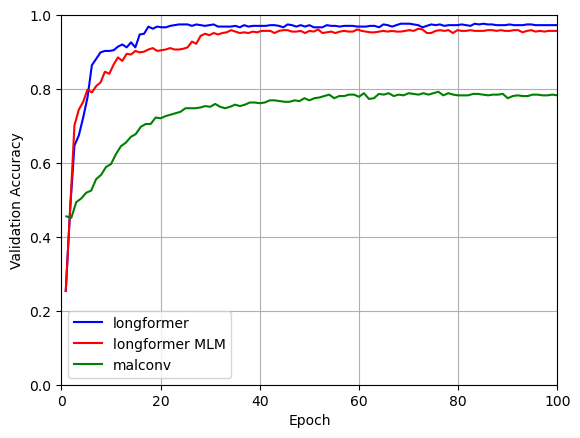

In [18]:
tokenizer = "Raw"
vocab_size = 262
tokenizer = "SentencePieceBPE"
vocab_size = 4102
base = OUTPUT / tokenizer / str(vocab_size) / "1000/10000/clf/1.0/"
tail = "log_history.json"
log_history_files = [
    base / "longformer" / "clf" / tail,
    base / "longformer" / "mlm" / tail,
    base / "malconv" / "clf" / tail,
]
for p in log_history_files:
    assert p.exists(), f"{p.as_posix()} does not exist."

logs = load_log_histories(*log_history_files)
logs = compress_log_histories(*logs)

labels = [
    "longformer",
    "longformer MLM",
    "malconv",
]
colors = {
    "longformer": "blue",
    "longformer MLM": "red",
    "malconv": "green",
}

for label, history in zip(labels, logs):
    x = []
    y = []
    for epoch, log in history.items():
        x.append(epoch)
        y.append(log["eval_accuracy"])
    plt.plot(x, y, label=label, color=colors[label])

plt.xlim(0, 100)
plt.ylim(0, 1.0)
plt.legend()
plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.savefig(HOME / f"figures/fig_2.png", dpi=600)

x=[0.16, 0.33, 0.49, 0.65, 0.82, 0.98, 1.14, 1.31, 1.47, 1.63, 1.79, 1.96, 2.12, 2.28, 2.45, 2.61, 2.77, 2.94, 3.1, 3.26, 3.43, 3.59, 3.75, 3.92, 4.08, 4.24, 4.4, 4.57, 4.73, 4.89, 5.06, 5.22, 5.38, 5.55, 5.71, 5.87, 6.04, 6.2, 6.36, 6.53, 6.69, 6.85, 7.01, 7.18, 7.34, 7.5, 7.67, 7.83, 7.99, 8.16, 8.32, 8.48, 8.65, 8.81, 8.97, 9.14, 9.3, 9.46, 9.62, 9.79, 9.95, 10.11, 10.28, 10.44, 10.6, 10.77, 10.93, 11.09, 11.26, 11.42, 11.58, 11.75, 11.91, 12.07, 12.23, 12.4, 12.56, 12.72, 12.89, 13.05, 13.21, 13.38, 13.54, 13.7, 13.87, 14.03, 14.19, 14.36, 14.52, 14.68, 14.85, 15.01, 15.17, 15.33, 15.5, 15.66, 15.82, 15.99, 16.15, 16.31, 16.48, 16.64, 16.8, 16.97, 17.13, 17.29, 17.46, 17.62, 17.78, 17.94, 18.11, 18.27, 18.43, 18.6, 18.76, 18.92, 19.09, 19.25, 19.41, 19.58, 19.74, 19.9, 20.07, 20.23, 20.39, 20.55, 20.72, 20.88, 21.04, 21.21, 21.37, 21.53, 21.7, 21.86, 22.02, 22.19, 22.35, 22.51, 22.68, 22.84, 23.0, 23.16, 23.33, 23.49, 23.65, 23.82, 23.98, 24.14, 24.31, 24.47, 24.63, 24.8, 24.96, 25

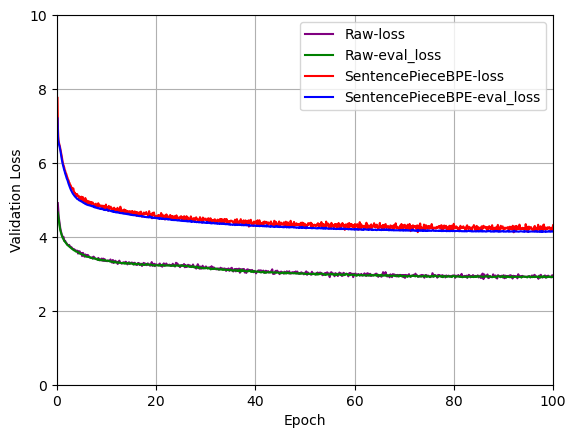

In [19]:
plt.close()

tail = "1000/10000/mlm/1.0/longformer/mlm_/log_history.json"
log_history_files = [
    OUTPUT / "Raw" / "262" / tail,
    OUTPUT / "SentencePieceBPE" / "4102" / tail,
]
for p in log_history_files:
    assert p.exists(), f"{p.as_posix()} does not exist."

logs = load_log_histories(*log_history_files)
logs = compress_log_histories(*logs)

labels = ["Raw", "SentencePieceBPE"]
colors = ["blue", "red", "green", "purple"]

for label, history in zip(labels, logs):
    x = []
    loss = []
    eval_loss = []
    for epoch, log in history.items():
        if "loss" not in log or "eval_loss" not in log:
            continue
        x.append(epoch)
        loss.append(log["loss"])
        eval_loss.append(log["eval_loss"])
    print(f"{x=}")
    print(f"{y=}")
    plt.plot(x, loss, label=f"{label}-loss", color=colors.pop())
    plt.plot(x, eval_loss, label=f"{label}-eval_loss", color=colors.pop())

plt.xlim(0, 100)
plt.ylim(0, 10.0)
plt.legend()
plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.savefig(HOME / "figures/fig_c.png", dpi=600)

In [35]:
test_metric_files = [p.with_name("test_results.json") for p in log_history_files]

for p in test_metric_files:
    print(p, p.exists())

test_metrics = []
for p in test_metric_files:
    assert p.exists()
    with open(p, "r") as fp:
        test_metrics.append(json.load(fp))
pprint(test_metrics)

/home/lk3591/Documents/code/RawByteClf/output/SentencePieceBPE/4102/1000/10000/clf/1.0/longformer/clf/test_results.json True
/home/lk3591/Documents/code/RawByteClf/output/SentencePieceBPE/4102/1000/10000/clf/1.0/longformer/mlm/test_results.json True
/home/lk3591/Documents/code/RawByteClf/output/SentencePieceBPE/4102/1000/10000/clf/1.0/malconv/clf/test_results.json True
[{'eval_accuracy': 1.0,
  'eval_loss': 0.015004349872469902,
  'eval_runtime': 9.9669,
  'eval_samples_per_second': 54.48,
  'eval_steps_per_second': 0.502},
 {'eval_accuracy': 0.988950276243094,
  'eval_loss': 0.040871284902095795,
  'eval_runtime': 10.0395,
  'eval_samples_per_second': 54.086,
  'eval_steps_per_second': 0.498},
 {'accuracy': 1.0, 'loss': 7.147447759052739e-05}]


OrderedDict([(0.88, {'loss': 2.0188, 'learning_rate': 4.956140350877193e-05, 'epoch': 0.88, 'step': 100, 'eval_loss': 1.9608466625213623, 'eval_accuracy': 0.25387596899224807, 'eval_runtime': 13.49, 'eval_samples_per_second': 38.25, 'eval_steps_per_second': 0.371}), (1.75, {'loss': 1.7952, 'learning_rate': 4.912280701754386e-05, 'epoch': 1.75, 'step': 200, 'eval_loss': 1.5263890027999878, 'eval_accuracy': 0.47093023255813954, 'eval_runtime': 16.7677, 'eval_samples_per_second': 30.773, 'eval_steps_per_second': 0.298}), (2.63, {'loss': 1.2754, 'learning_rate': 4.868421052631579e-05, 'epoch': 2.63, 'step': 300, 'eval_loss': 1.159995675086975, 'eval_accuracy': 0.7015503875968992, 'eval_runtime': 15.2586, 'eval_samples_per_second': 33.817, 'eval_steps_per_second': 0.328}), (3.51, {'loss': 1.0381, 'learning_rate': 4.824561403508772e-05, 'epoch': 3.51, 'step': 400, 'eval_loss': 0.9653812050819397, 'eval_accuracy': 0.7441860465116279, 'eval_runtime': 14.0895, 'eval_samples_per_second': 36.623,

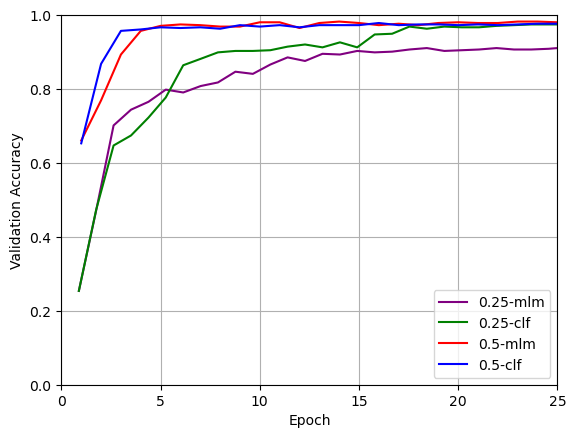

In [7]:
head = "SentencePieceBPE/4102/2500/10000/clf/1.0/longformer"
tail = "log_history.json"
log_history_files = [
    OUTPUT / "SentencePieceBPE/4102/1000/10000/clf/1.0/longformer" / "0.25" / "mlm" / tail,
    OUTPUT / "SentencePieceBPE/4102/1000/10000/clf/1.0/longformer" / "0.25" / "clf" / tail,
    OUTPUT / "SentencePieceBPE/4102/2500/10000/clf/1.0/longformer" / "0.5" / "mlm" / tail,
    OUTPUT / "SentencePieceBPE/4102/2500/10000/clf/1.0/longformer" / "0.5" / "clf" / tail,
]
for p in log_history_files:
    assert p.exists(), f"{p.as_posix()} does not exist."

logs = load_log_histories(*log_history_files)
logs = compress_log_histories(*logs)

print(logs[0])

labels = ["0.25-mlm", "0.25-clf", "0.5-mlm", "0.5-clf"]
colors = ["blue", "red", "green", "purple"]

for i, (label, history) in enumerate(zip(labels, logs)):
    x = []
    y = []
    for epoch, log in history.items():
        if "eval_accuracy" not in log:
            continue
        x.append(epoch)
        y.append(log["eval_accuracy"])
    plt.plot(x, y, label=label, color=colors.pop())

plt.xlim(0, 25)
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.savefig(HOME / "figures/fig_5.png", dpi=600)

CNN 1.0
LNG 0.996316758747698
LNG+MLM+TOK 0.992633517495396


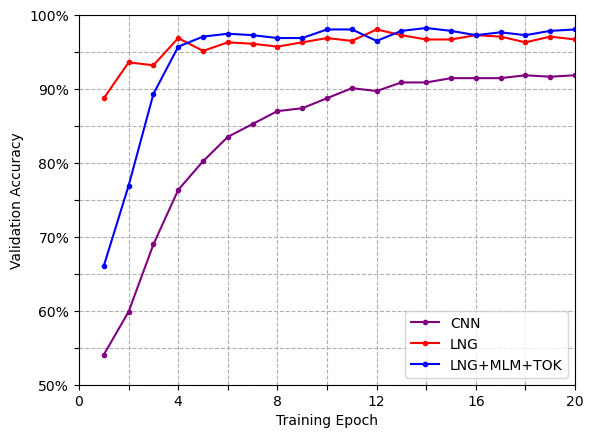

In [37]:
experiments = [
    OUTPUT / "Raw/262/1000/10000/clf/1.0/malconv/1.0/clf",
    OUTPUT / "Raw/262/1000/10000/clf/1.0/longformer/0.5/clf/",
    # OUTPUT / "Raw/262/1000/10000/clf/1.0/longformer/0.5/mlm/",
    OUTPUT / "SentencePieceBPE/4102/2500/10000/clf/1.0/longformer/0.5/mlm",
]
log_history_files = [p / "log_history.json" for p in experiments]
for p in log_history_files:
    assert p.exists(), f"{p.as_posix()} does not exist."

logs = load_log_histories(*log_history_files)
logs = compress_log_histories(*logs)

labels = [
    "CNN",
    "LNG",
    # "LNG+MLM",
    "LNG+MLM+TOK",
]
colors = [
    "blue",
    "red",
    # "green",
    "purple",
]

PLOT = {
    "epochs": 20,
    "x_tic_freq": 2,
    "x_tic_lab": 4,
    "y_tic_freq": 5,
    "y_tic_lab": 10,
}

plt.close()
for label, history in zip(labels, logs):
    x = []
    y = []
    for epoch, log in history.items():
        if "eval_accuracy" not in log:
            continue
        if epoch > PLOT["epochs"]:
            continue
        x.append(epoch)
        y.append(100 * log["eval_accuracy"])
    plt.plot(x, y, label=label, color=colors.pop(), marker=".")

plt.xlim(0, PLOT["epochs"])
plt.xticks(
    list(range(0, PLOT["epochs"] + 1, PLOT["x_tic_freq"])),
    [str(i) if i % PLOT["x_tic_lab"] == 0 else "" for i in range(0, PLOT["epochs"] + 1, PLOT["x_tic_freq"])],
)
plt.ylim(50, 100)
plt.yticks(
    list(range(50, 101, PLOT["y_tic_freq"])),
    [str(i) + "%" if i % PLOT["y_tic_lab"] == 0 else "" for i in range(50, 101, PLOT["y_tic_freq"])],
)
plt.grid(linestyle="--") # '-', '--', '-.', ':', ''
plt.legend()
plt.xlabel("Training Epoch")
plt.ylabel("Validation Accuracy")
plt.savefig(HOME / "figures/fig_6.png", dpi=600)

test_results_files = [p / "test_results.json" for p in experiments]
for p in test_results_files:
    assert p.exists(), f"{p.as_posix()} does not exist."
test_results = load_log_histories(*test_results_files)
for label, test_result in zip(labels, test_results):
    print(label, test_result["eval_accuracy"])

CNN 1.0
18M LNG 0.996316758747698
18M LNG+MLM 0.998158379373849
18M LNG+TOK 1.0
18M LNG+MLM+TOK 0.992633517495396
36M LNG 0.8471454880294659
36M LNG+TOK 0.5174953959484346
36M LNG+MLM+TOK 0.570902394106814


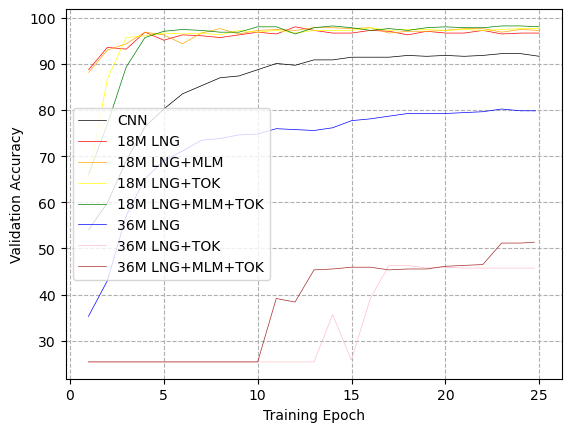

In [17]:
experiments = [
    OUTPUT / f"Raw/262/1000/10000/clf/1.0/malconv/{str(1 / 1)}/clf",
    OUTPUT / f"Raw/262/1000/10000/clf/1.0/longformer/{str(1 / 2)}/clf/",
    OUTPUT / f"Raw/262/1000/10000/clf/1.0/longformer/{str(1 / 2)}/mlm/",
    OUTPUT / f"SentencePieceBPE/4102/2500/10000/clf/1.0/longformer/{str(1 / 2)}/clf",
    OUTPUT / f"SentencePieceBPE/4102/2500/10000/clf/1.0/longformer/{str(1 / 2)}/mlm",
    OUTPUT / f"Raw/262/1000/10000/clf/1.0/longformer/{str(2 / 3)}/clf/",
    # OUTPUT / f"Raw/262/1000/10000/clf/1.0/longformer/{str(2 / 3)}/mlm/",
    OUTPUT / f"SentencePieceBPE/4102/2500/10000/clf/1.0/longformer/{str(2 / 3)}/clf",
    OUTPUT / f"SentencePieceBPE/4102/2500/10000/clf/1.0/longformer/{str(2 / 3)}/mlm",
]
log_history_files = [p / "log_history.json" for p in experiments]
for i, p in enumerate(log_history_files):
    assert p.exists(), f"{i}: {p.as_posix()} does not exist."

logs = load_log_histories(*log_history_files)
logs = compress_log_histories(*logs)

labels_colors = [
    ("CNN", "black"),
    ("18M LNG", "red"),
    ("18M LNG+MLM", "orange"),
    ("18M LNG+TOK", "yellow"),
    ("18M LNG+MLM+TOK", "green"),
    ("36M LNG", "blue"),
    # ("36M LNG+MLM", "purple"),
    ("36M LNG+TOK", "pink"),
    ("36M LNG+MLM+TOK", "brown"),
]

PLOT = {
    "epochs": 25,
    "x_tic_freq": 2,
    "x_tic_lab": 4,
    "y_tic_freq": 5,
    "y_tic_lab": 10,
}

plt.close()
for (label, color), history in zip(labels_colors, logs):
    x = []
    y = []
    for epoch, log in history.items():
        if "eval_accuracy" not in log:
            continue
        if epoch > PLOT["epochs"]:
            continue
        x.append(epoch)
        y.append(100 * log["eval_accuracy"])
    plt.plot(x, y, label=label, color=color, linewidth=0.5)

# plt.xlim(0, PLOT["epochs"])
# plt.xticks(
#     list(range(0, PLOT["epochs"] + 1, PLOT["x_tic_freq"])),
#     [str(i) if i % PLOT["x_tic_lab"] == 0 else "" for i in range(0, PLOT["epochs"] + 1, PLOT["x_tic_freq"])],
# )
# plt.ylim(50, 100)
# plt.yticks(
#     list(range(50, 101, PLOT["y_tic_freq"])),
#     [str(i) + "%" if i % PLOT["y_tic_lab"] == 0 else "" for i in range(50, 101, PLOT["y_tic_freq"])],
# )
plt.grid(linestyle="--")
plt.legend()
plt.xlabel("Training Epoch")
plt.ylabel("Validation Accuracy")
plt.savefig(HOME / "figures/fig_7.png", dpi=600)

test_results_files = [p / "test_results.json" for p in experiments]
for p in test_results_files:
    assert p.exists(), f"{p.as_posix()} does not exist."
test_results = load_log_histories(*test_results_files)
for (label, _), test_result in zip(labels_colors, test_results):
    print(label, test_result["eval_accuracy"])

In [ ]:
0.6666666666666666
0.6666666666666666

/home/lk3591/Documents/code/RawByteClf/output/all/Raw/262/1000/10000/clf/1.0/longformer/0.25/clf/test_results.json True
[{'eval_accuracy': 0.7258509659613616,
  'eval_loss': 0.895021915435791,
  'eval_runtime': 8.4311,
  'eval_samples_per_second': 128.928,
  'eval_steps_per_second': 2.016}]


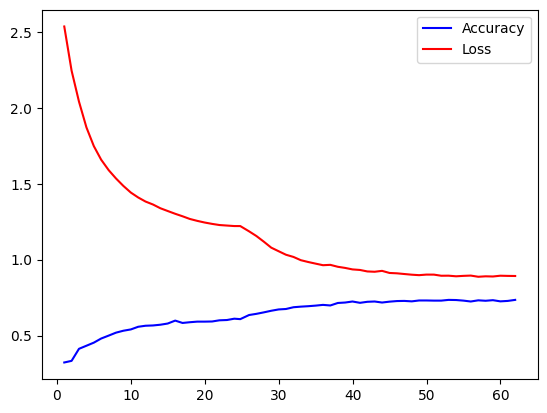

In [14]:
from sklearn.metrics import confusion_matrix


experiments = [
    OUTPUT / f"all/Raw/262/1000/10000/clf/1.0/longformer/{str(1 / 4)}/clf/"
]
log_history_files = [p / "log_history.json" for p in experiments]
for i, p in enumerate(log_history_files):
    assert p.exists(), f"{i}: {p.as_posix()} does not exist."

logs = load_log_histories(*log_history_files)
logs = compress_log_histories(*logs)

labels_colors = [
    ("LNG", "black"),
]

plt.close()
for (label, color), history in zip(labels_colors, logs):
    x = []
    y = []
    y_2 = []
    for epoch, log in history.items():
        if "eval_accuracy" not in log:
            continue
        x.append(epoch)
        y.append(log["eval_accuracy"])
        y_2.append(log["eval_loss"])
    plt.plot(x, y, label="Accuracy", color="blue")
    plt.plot(x, y_2, label="Loss", color="red")

plt.legend()

test_metric_files = [p.with_name("test_results.json") for p in log_history_files]

for p in test_metric_files:
    print(p, p.exists())

test_metrics = []
for p in test_metric_files:
    assert p.exists()
    with open(p, "r") as fp:
        test_metrics.append(json.load(fp))
pprint(test_metrics)

In [5]:
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)

p = Path("/home/lk3591/Documents/code/RawByteClf/output/all/Raw/262/1000/10000/clf/1.0/longformer/0.6666666666666666/clf/")
predictions = np.loadtxt(p / "predictions.txt", dtype=np.int32)
labels = np.loadtxt(p / "labels.txt", dtype=np.int32)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


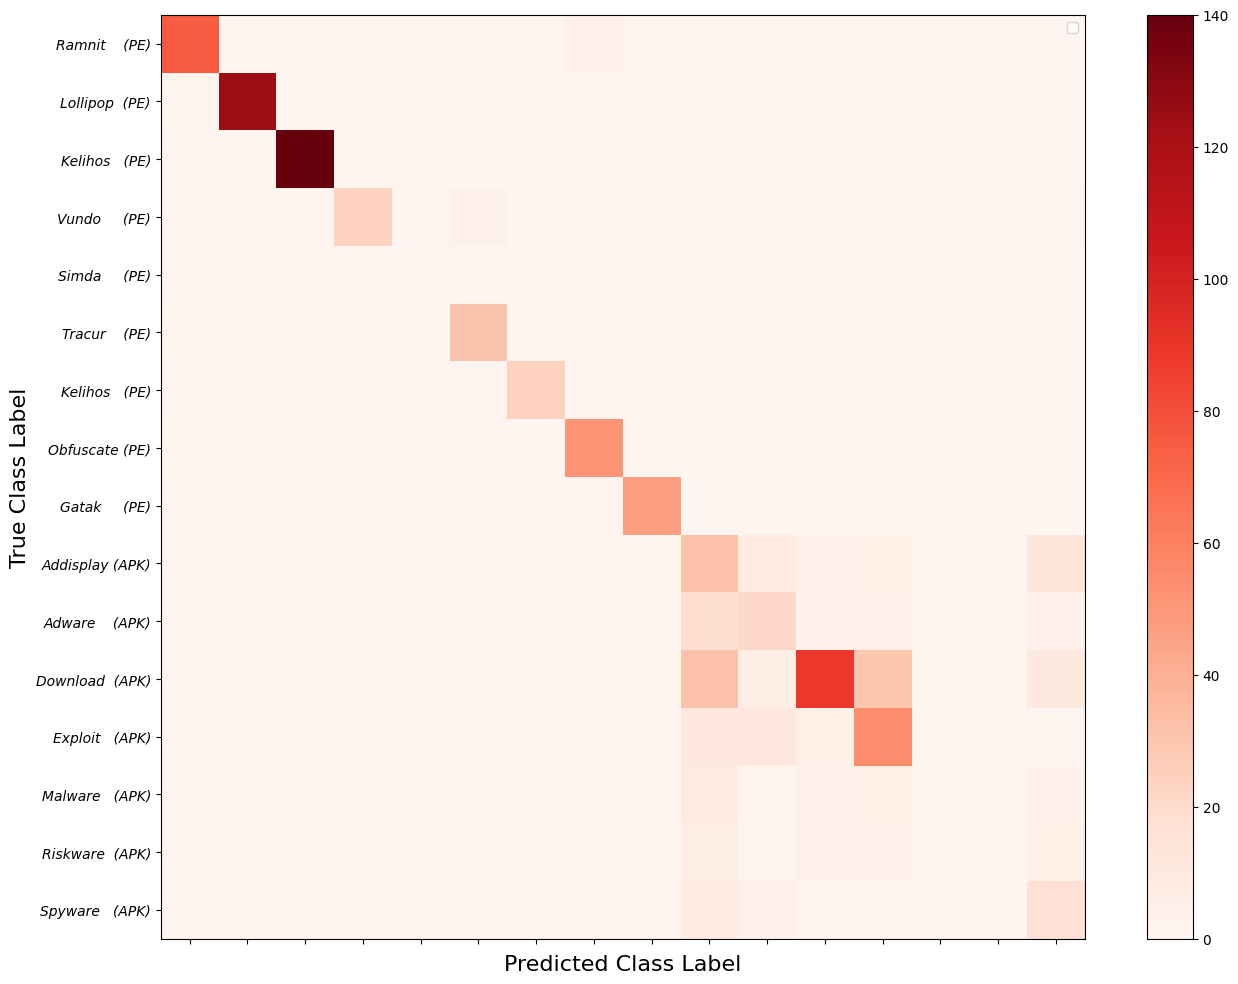

In [56]:
# plt.rcParams['text.usetex'] = True

LABELS = (
    "Ramnit",  # 0
    "Lollipop",  # 1
    "Kelihos",  # 2
    "Vundo",  # 3
    "Simda",  # 4
    "Tracur",  # 5
    "Kelihos",  # 6
    "Obfuscate",  # 7
    "Gatak",  # 8
    "Addisplay",  # 9
    "Adware",  # 10
    "Download",  # 11
    "Exploit",  # 12
    "Malware",  # 13
    "Riskware",  # 14
    "Spyware",  # 15
)

LABELS = [l + " " * (10 - len(l)) for l in LABELS]
LABELS = [l + "(PE)" if i < 9 else l + "(APK)" for i, l in enumerate(LABELS)]

cmaps = [
    'Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds',
    'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
    'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn',
]
display_labels = [f"PE_{i}" for i in range(1, 10)] + [f"APK {i}" for i in range(10, 17)]
# display_labels = [r'\textbf{time (s)}'] * 16
fig, ax = plt.subplots(figsize=(16, 12))
ConfusionMatrixDisplay.from_predictions(
    labels,
    predictions,
    include_values=False,
    xticks_rotation="vertical",
    cmap='Reds',
    display_labels=LABELS,
    ax=ax,
)
# ax.axvline(8.5, color='black', linewidth=0.5, linestyle="--", )
ax.set_xlabel("Predicted Class Label", fontsize=16)
ax.set_ylabel("True Class Label", fontsize=16)
# ax.tick_params(axis='y', colors='red')
ax.set_xticks(np.arange(0, 16, 1), [""] * 16)
# for i, t in enumerate(ax.yaxis.get_ticklabels(), 1):
#     if i < 10:
#         t.set_color('red')
#     else:
#         t.set_color('blue')

ax.set_yticklabels(LABELS, style='italic')


ax.legend()

fig.show()

fig.savefig("./fig_3.png", dpi=600)

In [16]:
ax.show()

AttributeError: 'Axes' object has no attribute 'show'

In [1]:
plt.show()

NameError: name 'plt' is not defined